# interp_sg_cressman 说明

站点 → 格点 **Cressman** 插值：按影响半径列表 `r_list` 从大到小逐级用邻近站点做加权插值；可选背景场经双线性对齐到目标网格作为初值。

$$
w(d,R)=\frac{R^{2}-d^{2}}{R^{2}+d^{2}}\quad(d<R),\qquad w=0\quad(d\ge R)
$$

有邻站的格点写为站点加权平均；无邻站的格点保留背景（或 0 场）。

## 1. 算法原理

目标是把不规则站点场插到规则网格，并可通过多半径逐级加密局地结构。

1. **子集与缺测**  
   站点按 `member` / `level` / `time` / `dtime` 拆分；缺测丢弃后再插值，最后拼接。

2. **距离与邻站**  
   站点与目标网格经纬度经 `lon_lat_to_cartesian` 转到笛卡尔坐标（地球半径，距离单位为**米**），用 `cKDTree` 为每个格点查最多 `nearNum` 个邻近站。

3. **初值**  
   若提供背景场，先经 `interp_gg_linear` 对齐到目标网格作为初值；否则初值为 0 场。`outer_value` 控制背景越界填充。

4. **Cressman 加权写回**  
   对 `r_list` 中每个半径 \(R\)（通常由大到小）：

   - 仅处理最近邻站距离 \(d_0<R\) 的格点；
   - 对各邻近站计算权重 \(w=(R^{2}-d^{2})/(R^{2}+d^{2})\)，\(w<0\) 置 0；
   - 格点值写为

   $$
   V_g=\frac{\sum_i w_i\,O_i}{\sum_i w_i}
   $$

   从未落入任一半径的格点保持初值。

## 2. 算法实现方式

| 层级 | 路径 | 说明 |
|------|------|------|
| 算法核 | `src/interp_sg_cressman.py` | `interp_sg_cressman`、`InterpSGCressmanPlugin` |
| 调度 | `src/runner.py` | `process`：读站/背景 → 插值 → 写 Micaps4 |
| 配置 | `src/utils/util_env.py` | 读 `resource/interp_sg_cressman.ini` |
| CLI | `cli/__main__.py` | argparse → `process` |

**主流程（`interp_sg_cressman`）**

1. `sele_by_para(..., drop_IV=True)` 去缺测，`split` 按维拆分。  
2. 由目标 `grid` 与当前子集构造 `grid2`（填入 time/dtime/level/member）。  
3. 站、格点转笛卡尔坐标，`cKDTree.query` 得距离与邻站下标。  
4. 背景场 `interp_gg_linear` 对齐（可选），展平为初值数组。  
5. 按 `r_list` 逐半径算权重并写回有邻站的格点，`concat` 各子集。

**目标网格优先级（`runner._resolve_target_grid`）**

1. CLI/ini 显式 `glon`+`glat`，或 `domain=sou,nor,wst,est,dlon,dlat`  
2. `background_path` 背景场水平网格  
3. `grid_template_path` 模板格点（仅取网格）

**调用形态**

- 函数：`interp_sg_cressman(sta, grid, r_list, background=..., nearNum=..., outer_value=...)`  
- 插件：`InterpSGCressmanPlugin(r_list=...)(sta, grid, background=...)`  
- 产品入口：`from runner import process` / `python -m cli`

入参为 meteva / meteva_base 站点与网格对象。仓库根另有共享 `utils/interp_sg_cressman_plugin.py`，逻辑应与本包 `src/interp_sg_cressman.py` 保持一致。

In [ ]:
from pathlib import Path
import sys

root = Path("..").resolve()
sys.path[:0] = [str(root), str(root / "src")]

from utils.util_env import get_cressman_params, get_resolved_paths

print("路径:", get_resolved_paths())
print("插值参数:", get_cressman_params())


## 3. 算法参数说明

### 3.1 插值参数（算法核 / ini / CLI 共用）

| 参数 | ini 键 | CLI | 默认 | 含义 |
|------|--------|-----|------|------|
| `r_list` | `r_list` | `--r-list` | `60000,40000,20000` | 影响半径列表（**米**），按顺序逐级订正 |
| `nearNum` | `nearNum` | `--near-num` | 100 | KDTree 邻近站上限（不超过实际站数） |
| `outer_value` | `outer_value` | `--outer-value` | `0` | 背景场双线性越界填充；ini 留空表示不设 |
| `glon` / `glat` | `glon` / `glat` | `--glon` / `--glat` | 空 | `slon,elon,dlon` / `slat,elat,dlat` |
| `domain` | `domain` | `--domain` | 空 | `sou,nor,wst,est,dlon,dlat`（与 glon/glat 二选一） |

`r_list` 单位必须与 `lon_lat_to_cartesian` 一致（米）。例如 60 km、40 km、20 km 写作 `60000,40000,20000`。

### 3.2 路径与格式（ini）

| 键 | 默认 | 含义 |
|----|------|------|
| `sta_path` | 空 | 输入站点 |
| `output_path` | `resource/output/cressman.m4` | 输出 Micaps4 |
| `background_path` | 空 | 可选背景格点 |
| `grid_template_path` | 空 | 可选网格模板（仅取水平网格） |
| `sta_type` | `m3` | `m3` / `nc` |
| `background_type` / `grid_template_type` | `m4` | `m4` / `nc` |

未在 CLI 给出的项一律回落到 `resource/interp_sg_cressman.ini`。

## 4. 算法使用说明

**环境**：项目根目录 `interp_sg_cressman/`；依赖 `numpy` / `scipy` / `meteva` / `meteva_base`；共享 `utils.base_plugin`、`utils.interp_gg_pulgin`（仓库根 `utils/`）。

**步骤**

1. 编辑 `resource/interp_sg_cressman.ini`，填写 `sta_path`，并指定目标网格（`domain` / `glon`+`glat` / `background_path` / `grid_template_path` 之一）。  
2. 任选一种入口运行（见下节 CLI，或模块 / 直跑）。  
3. 查看输出 Micaps4；日志模板见 ini 中 `log_file`。

**模块调用**

```python
from runner import process
process(sta_path="a.m3", domain=[20, 50, 70, 140, 0.1, 0.1],
        r_list=[60000, 40000, 20000], output_path="out.m4")

# 或直接调算法核（已有 meteva 对象时）
from interp_sg_cressman import interp_sg_cressman, InterpSGCressmanPlugin
grd = interp_sg_cressman(sta, grid, r_list=[60000, 40000, 20000])
grd = InterpSGCressmanPlugin(r_list=[60000, 40000, 20000])(sta, grid, background=bg)
```

**直跑**

```bash
python src/runner.py
```

（未传参时同样读 ini。）

## 5. CLI 调用说明

在仓库根执行：

```bash
python -m cli --help
python -m cli
python -m cli --sta=a.m3 --background=b.m4 --output=out.m4
python -m cli --sta=a.m3 --domain=20,50,70,140,0.1,0.1 --r-list=60000,40000,20000
python -m cli --sta=a.m3 --glon=70,140,0.1 --glat=15,55,0.1 --near-num=100
```

| 参数 | 说明 |
|------|------|
| `--sta` | 输入站点 Micaps3/NC |
| `--output` | 输出格点 Micaps4 |
| `--background` | 可选背景格点 |
| `--grid-template` | 可选网格模板格点（仅取水平网格） |
| `--r-list` | Cressman 半径列表（米），如 `60000,40000,20000` |
| `--near-num` | KDTree 邻近站点数 |
| `--outer-value` | 背景场越界填充值 |
| `--glon` / `--glat` | 目标经纬度定义 |
| `--domain` | `sou,nor,wst,est,dlon,dlat` |

省略的参数从 `resource/interp_sg_cressman.ini` 读取。

## 6. 示例：站点 Cressman 插值并出图

读 `resource/input/ecmf` 站点 → 本包 `interp_sg_cressman` → `contourf` 填色图（对应 `test/test_interp.py`）。示例半径沿用该对照脚本；业务默认见 ini 的 `60000,40000,20000`（米）。

<xarray.DataArray 'data0' (member: 1, level: 1, time: 1, dtime: 1, lat: 401,
                           lon: 701)>
array([[[[[[0.       , 0.       , 0.       , ..., 0.       ,
            0.       , 0.       ],
           [0.       , 0.       , 0.       , ..., 0.       ,
            0.       , 0.       ],
           [0.       , 0.       , 0.       , ..., 0.       ,
            0.       , 0.       ],
           ...,
           [0.       , 0.       , 0.       , ..., 1.8679103,
            1.6729763, 1.477517 ],
           [0.       , 0.       , 0.       , ..., 1.7683368,
            1.6023436, 1.4124001],
           [0.       , 0.       , 0.       , ..., 1.7335852,
            1.5456545, 1.3128365]]]]]], dtype=float32)
Coordinates:
  * member   (member) <U5 'data0'
  * level    (level) float32 0.0
  * time     (time) datetime64[ns] 2000-01-04T08:00:00
  * dtime    (dtime) int32 0
  * lat      (lat) float64 15.0 15.1 15.2 15.3 15.4 ... 54.6 54.7 54.8 54.9 55.0
  * lon      (lon) float64 7

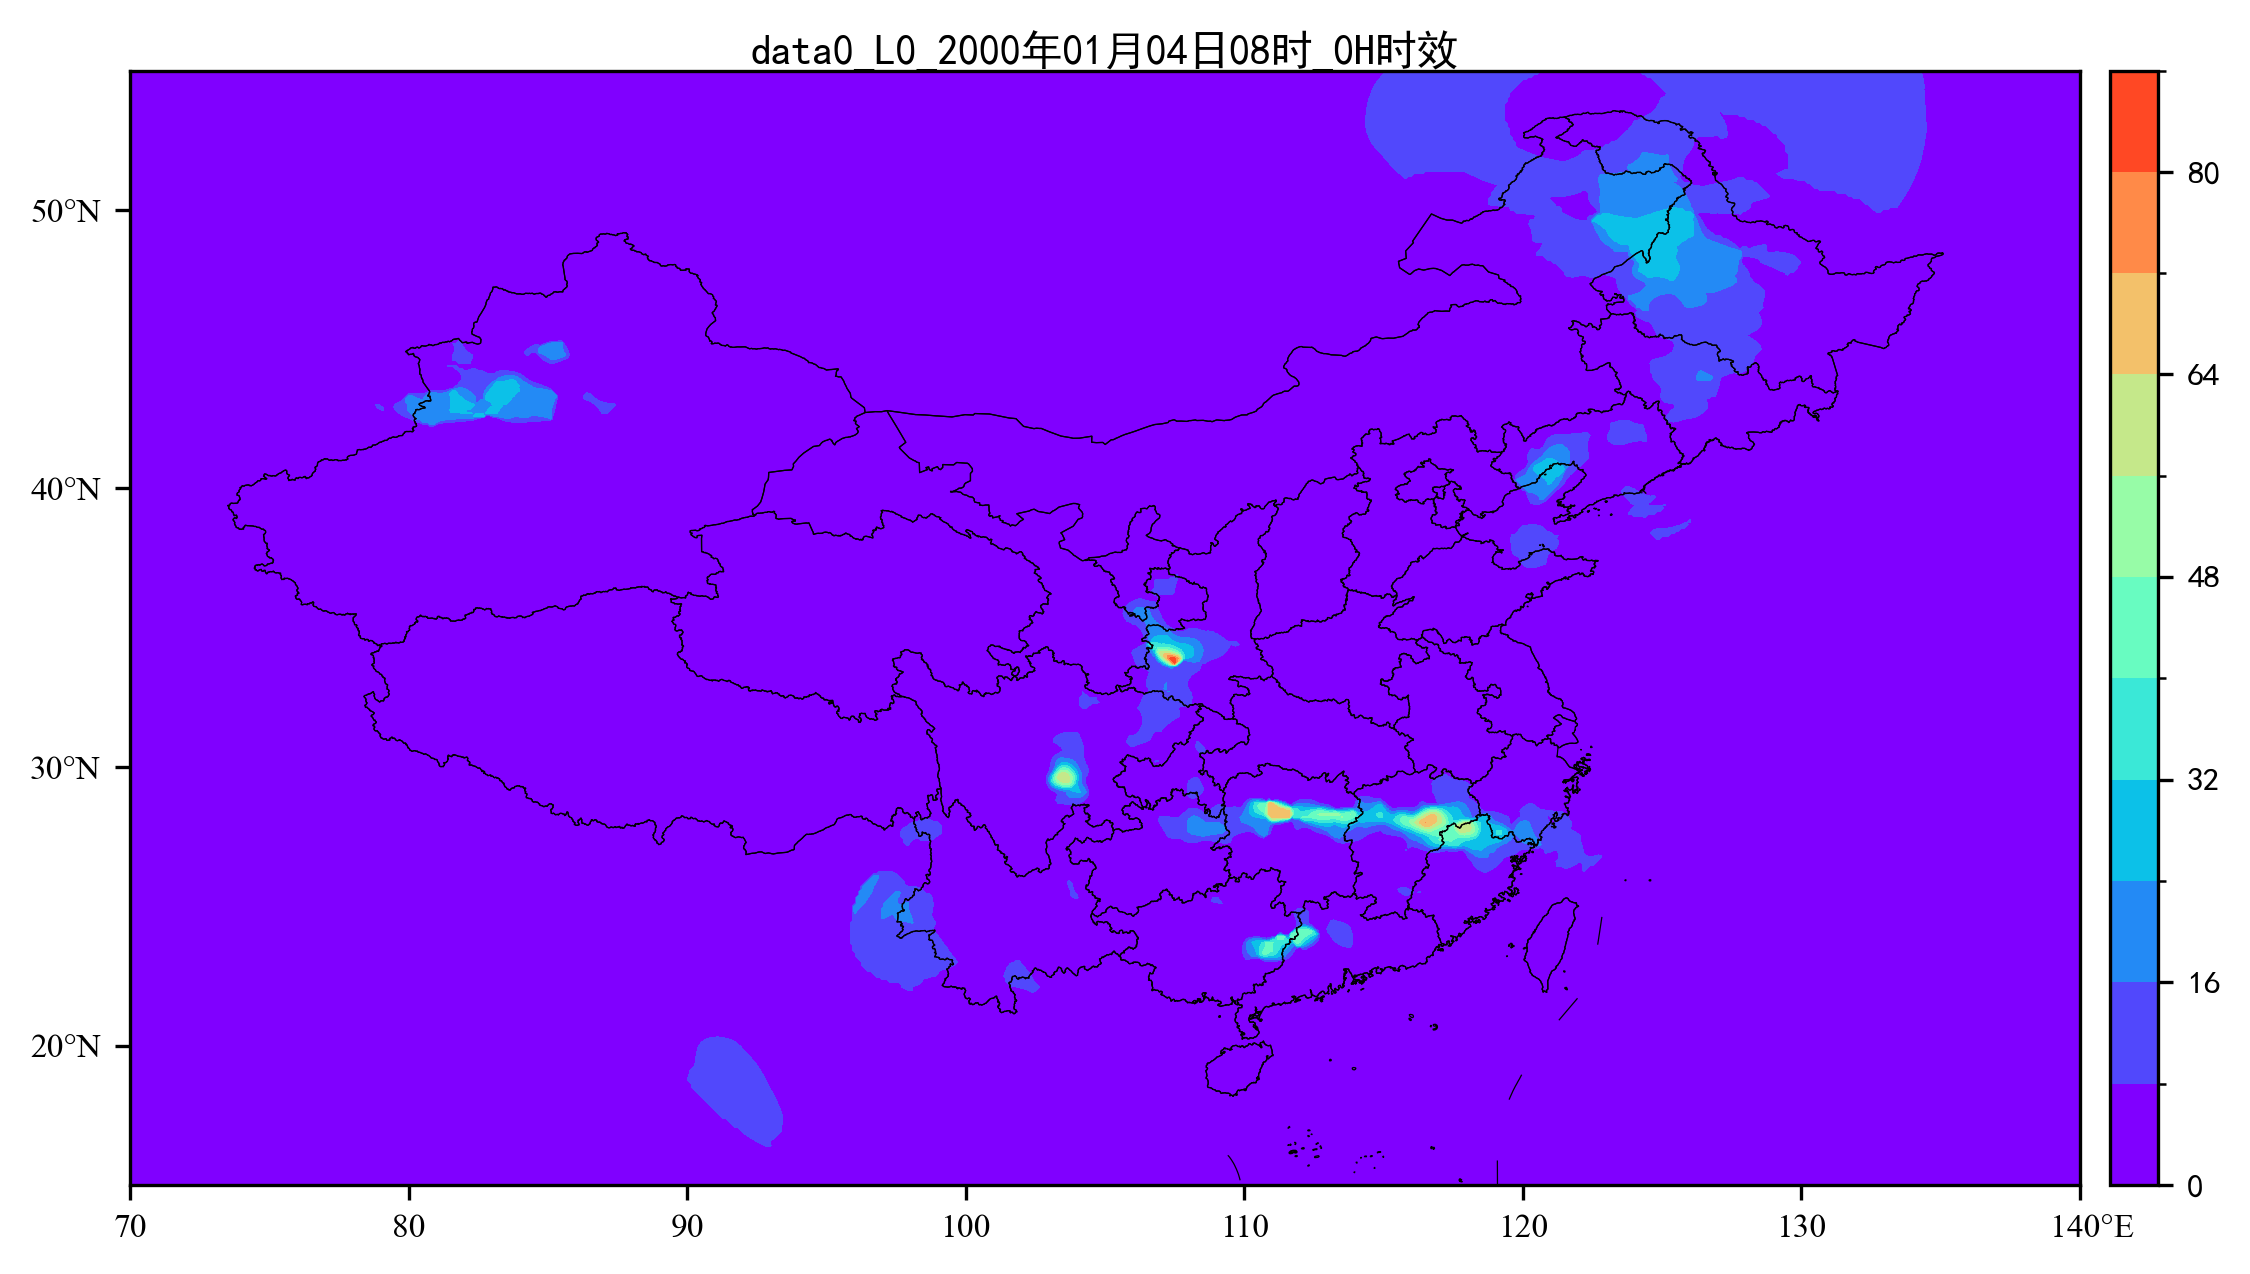

In [ ]:
from pathlib import Path
import sys

from IPython.display import Image, display

# notebook 在 nbs/ 下，仓库根为上一级
root = Path("..").resolve()
sys.path[:0] = [str(root), str(root / "src")]

import meteva_base as meb
from interp_sg_cressman import interp_sg_cressman

sta_file = root / "resource" / "input" / "ecmf" / "2026052200.036.m3"
sta = meb.read_stadata_from_micaps3(str(sta_file))
grid0 = meb.grid([70, 140, 0.1], [15, 55, 0.1])

grd1 = interp_sg_cressman(sta, grid0, r_list=[1000, 200, 100, 50], nearNum=100)
print(grd1)
meb.plot_tools.contourf_2d_grid(grd1)
